In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle



In [2]:
df = pd.read_csv("cyclone_dataset.csv")
print(df.head())

   Sea_Surface_Temperature  Atmospheric_Pressure   Humidity  Wind_Shear  \
0                27.498160           1008.521429  89.279758   13.979877   
1                28.404460           1001.242177  60.823380   19.548648   
2                27.216969            995.742693  77.277801    9.368437   
3                27.824280           1003.555279  67.986951   12.713517   
4                26.260206           1008.466566  98.625281   17.125960   

   Vorticity  Latitude  Ocean_Depth  Proximity_to_Coastline  \
0   0.000020  8.119890    76.137625                1.366176   
1   0.000084  9.246782   131.821235                0.683405   
2   0.000063  7.789877   181.465092                0.866362   
3   0.000061  5.929008   323.395183                0.670524   
4   0.000034  6.953442   357.904862                0.940152   

   Pre_existing_Disturbance  Cyclone  
0                         1        1  
1                         1        1  
2                         1        1  
3             

In [3]:
df.tail()

,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
1995,24.444059,1019.783538,58.691379,15.306127,0.000034,22.229769,2769.879093,1.487565,0,0
1996,23.049400,1017.971950,74.193806,10.104250,0.000047,25.230303,3533.586214,1.855625,0,0
1997,23.736830,1020.874352,38.880991,13.183351,0.000033,32.402860,4472.888270,1.643740,0,0
1998,24.203914,1008.284827,79.000021,16.393914,0.000037,25.639636,3081.710478,1.393481,0,0
1999,27.718585,1014.292058,76.889382,10.151828,0.000029,29.343738,3750.892839,1.904977,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sea_Surface_Temperature   2000 non-null   float64
 1   Atmospheric_Pressure      2000 non-null   float64
 2   Humidity                  2000 non-null   float64
 3   Wind_Shear                2000 non-null   float64
 4   Vorticity                 2000 non-null   float64
 5   Latitude                  2000 non-null   float64
 6   Ocean_Depth               2000 non-null   float64
 7   Proximity_to_Coastline    2000 non-null   float64
 8   Pre_existing_Disturbance  2000 non-null   int64  
 9   Cyclone                   2000 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 156.4 KB


In [5]:
df

,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
0,27.498160,1008.521429,89.279758,13.979877,0.000020,8.119890,76.137625,1.366176,1,1
1,28.404460,1001.242177,60.823380,19.548648,0.000084,9.246782,131.821235,0.683405,1,1
2,27.216969,995.742693,77.277801,9.368437,0.000063,7.789877,181.465092,0.866362,1,1
3,27.824280,1003.555279,67.986951,12.713517,0.000061,5.929008,323.395183,0.670524,1,1
4,26.260206,1008.466566,98.625281,17.125960,0.000034,6.953442,357.904862,0.940152,1,1
...,...,...,...,...,...,...,...,...,...,...
1995,24.444059,1019.783538,58.691379,15.306127,0.000034,22.229769,2769.879093,1.487565,0,0
1996,23.049400,1017.971950,74.193806,10.104250,0.000047,25.230303,3533.586214,1.855625,0,0
1997,23.736830,1020.874352,38.880991,13.183351,0.000033,32.402860,4472.888270,1.643740,0,0
1998,24.203914,1008.284827,79.000021,16.393914,0.000037,25.639636,3081.710478,1.393481,0,0


In [6]:
df.describe()

,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,26.011795,1003.390161,67.204883,16.129547,0.000039,20.057002,1433.043855,1.245077,0.500000,0.500000
std,2.695970,12.021871,17.727458,6.221843,0.000026,7.528196,1524.801300,0.387344,0.500125,0.500125
min,20.014982,980.033363,30.015487,5.010753,0.000001,5.004541,50.005236,0.500031,0.000000,0.000000
25%,24.074962,994.466175,55.188218,11.413949,0.000018,15.222078,261.794807,0.983213,0.000000,0.000000
50%,26.662512,1004.708218,68.635351,15.589793,0.000034,20.014008,473.034788,1.244601,0.500000,0.500000
75%,28.049755,1012.159534,78.975341,19.792779,0.000051,24.909619,2557.053097,1.498208,1.000000,1.000000
max,29.997655,1024.986477,99.955704,29.986702,0.000100,34.993464,4988.711471,1.999505,1.000000,1.000000


In [7]:
df.isnull().sum()

Sea_Surface_Temperature     0
Atmospheric_Pressure        0
Humidity                    0
Wind_Shear                  0
Vorticity                   0
Latitude                    0
Ocean_Depth                 0
Proximity_to_Coastline      0
Pre_existing_Disturbance    0
Cyclone                     0
dtype: int64

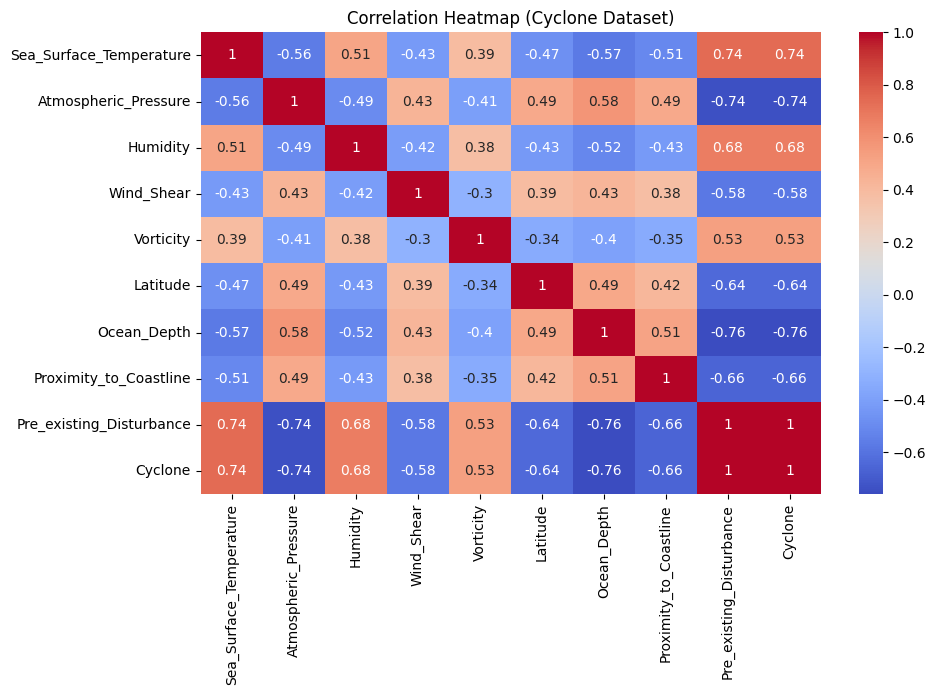

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Cyclone Dataset)")
plt.show()

In [9]:
X = df.drop("Cyclone", axis=1)   # input features
y = df["Cyclone"]                # target label


In [10]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
print("\n🌟 Feature Importance extracted successfully:\n")
print(feature_importance.sort_values(ascending=False))



🌟 Feature Importance extracted successfully:

Pre_existing_Disturbance    0.439163
Ocean_Depth                 0.233321
Sea_Surface_Temperature     0.133751
Atmospheric_Pressure        0.107120
Humidity                    0.046373
Proximity_to_Coastline      0.014970
Latitude                    0.011625
Vorticity                   0.010996
Wind_Shear                  0.002682
dtype: float64


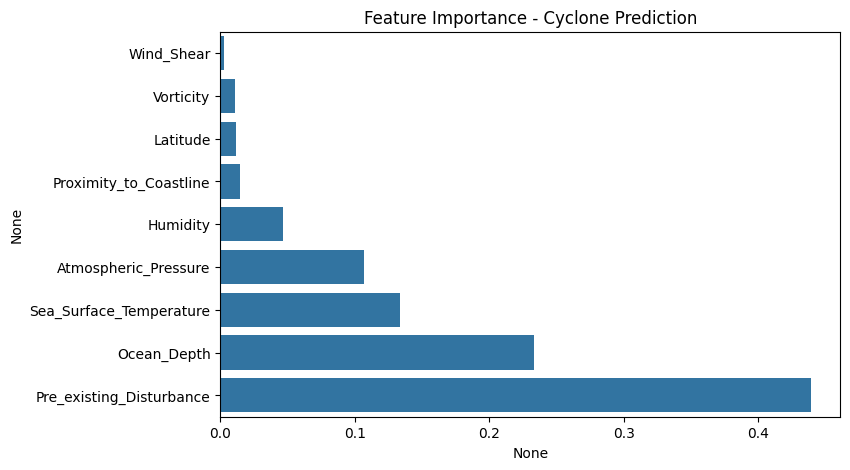

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.sort_values(), y=feature_importance.sort_values().index)
plt.title("Feature Importance - Cyclone Prediction")
plt.show()


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)


In [15]:
print("\n Model Trained Successfully")
print("\n Accuracy:", accuracy_score(y_test, y_pred))



 Model Trained Successfully

 Accuracy: 1.0


In [16]:
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))



 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       199

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [17]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:

[[201   0]
 [  0 199]]


In [18]:
pickle.dump(rf_model, open("cyclone_model.pkl", "wb"))
print("\nModel saved as cyclone_model.pkl\n")



Model saved as cyclone_model.pkl

